In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import pickle

In [37]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
df = pd.read_csv("car.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19109 entries, 0 to 19108
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   brand                        19107 non-null  object 
 1   model                        19107 non-null  object 
 2   year                         19107 non-null  float64
 3   mileage                      19107 non-null  float64
 4   engine                       19062 non-null  object 
 5   engine_size                  17860 non-null  float64
 6   transmission                 19004 non-null  object 
 7   automatic_transmission       19107 non-null  float64
 8   fuel_type                    19107 non-null  object 
 9   drivetrain                   19107 non-null  object 
 10  min_mpg                      16103 non-null  float64
 11  max_mpg                      16103 non-null  float64
 12  damaged                      18940 non-null  float64
 13  first_owner     

In [4]:
df.shape

(19109, 36)

In [5]:
df.isnull().sum()

brand                             2
model                             2
year                              2
mileage                           2
engine                           47
engine_size                    1249
transmission                    105
automatic_transmission            2
fuel_type                         2
drivetrain                        2
min_mpg                        3006
max_mpg                        3006
damaged                         169
first_owner                     306
personal_using                  189
turbo                             2
alloy_wheels                      2
adaptive_cruise_control           2
navigation_system                 2
power_liftgate                    2
backup_camera                     2
keyless_start                     2
remote_start                      2
sunroof/moonroof                  2
automatic_emergency_braking       2
stability_control                 2
leather_seats                     2
memory_seat                 

In [6]:
df.describe(include="all")

,brand,model,year,mileage,engine,engine_size,transmission,automatic_transmission,fuel_type,drivetrain,...,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,interior_color,exterior_color,price
count,19107,19107,19107.000000,19107.000000,19062,17860.000000,19004,19107.000000,19107,19107,...,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,17952,18900,19107
unique,25,3498,NaN,NaN,1163,NaN,189,NaN,10,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,957,1941,9088
top,Audi,Romeo Giulia Ti,NaN,NaN,2.0L I4 16V GDI DOHC Turbo,NaN,8-Speed Automatic,NaN,Gasoline,Four-wheel Drive,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Black,Black,29995
freq,855,169,NaN,NaN,2324,NaN,5403,NaN,17207,10824,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7432,1405,61
mean,NaN,NaN,2017.773120,47947.087403,NaN,2.973191,NaN,0.917098,NaN,NaN,...,0.696603,0.486000,0.148741,0.387240,0.870100,0.351547,0.485320,NaN,NaN,NaN
std,NaN,NaN,4.996385,38285.061200,NaN,5.478008,NaN,0.275741,NaN,NaN,...,0.459737,0.499817,0.355843,0.487132,0.336202,0.477466,0.499798,NaN,NaN,NaN
min,NaN,NaN,1962.000000,0.000000,NaN,0.000000,NaN,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,2016.000000,19307.000000,NaN,2.000000,NaN,1.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,NaN,2019.000000,39141.000000,NaN,2.500000,NaN,1.000000,NaN,NaN,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,NaN,2021.000000,68431.500000,NaN,3.500000,NaN,1.000000,NaN,NaN,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN


In [9]:
df["price"].head(10)

0     36789
1     39993
2     46986
3    141999
4     21595
5      9400
6     34000
7     49495
8     35999
9     33995
Name: price, dtype: object

In [10]:
df["price"].tail(10)

19099     23490
19100     98555
19101    115888
19102     21525
19103     31684
19104     30023
19105     42500
19106     43999
19107     26998
19108     15382
Name: price, dtype: object

In [19]:
df["price"].dtype

dtype('O')

In [11]:
df["brand"].value_counts()


brand
Audi             855
Hyundai          843
Ford             835
Volvo            831
FIAT             813
Maserati         813
Volkswagen       812
Porsche          809
Jaguar           808
Honda            803
Cadillac         801
Nissan           795
Kia              792
Mercedes-Benz    788
Land             787
Mitsubishi       782
Mazda            780
Alfa             774
MINI             772
BMW              760
Lexus            755
Jeep             749
Chevrolet        735
Toyota           704
Suzuki           111
Name: count, dtype: int64

In [23]:
df["fuel_type"].value_counts()

fuel_type
Gasoline                  17207
Hybrid                      839
Electric                    518
Diesel                      248
E85 Flex Fuel               210
Unknown                      81
B                             1
flex_fuel                     1
Premium Unleaded              1
Compressed Natural Gas        1
Name: count, dtype: int64

In [24]:
df["drivetrain"].value_counts()

drivetrain
Four-wheel Drive     10824
Front-wheel Drive     5126
Rear-wheel Drive      3065
Unknown                 91
2WD                      1
Name: count, dtype: int64

In [26]:
df["transmission"].value_counts().head(10)

transmission
8-Speed Automatic                    5403
6-Speed Automatic                    3108
Automatic                            2755
Automatic CVT                        1585
9-Speed Automatic                    1035
7-Speed Automatic with Auto-Shift     705
10-Speed Automatic                    660
6-Speed Manual                        599
5-Speed Automatic                     472
1-Speed Automatic                     399
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='brand'>

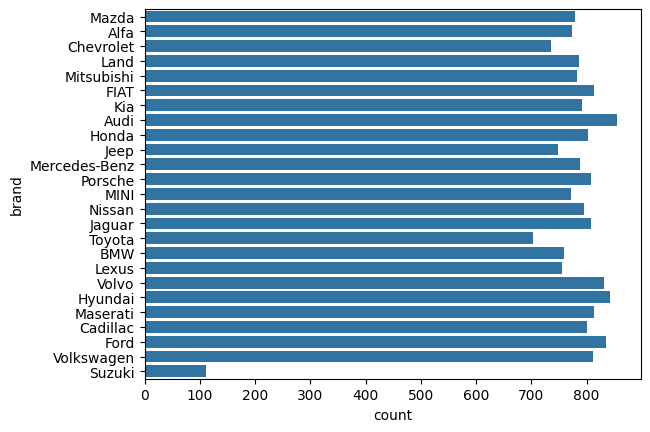

In [33]:
sns.countplot(df["brand"])

In [7]:
numerical_cols = df.select_dtypes(include="number").columns

print(numerical_cols)

Index(['year', 'mileage', 'engine_size', 'automatic_transmission', 'min_mpg',
       'max_mpg', 'damaged', 'first_owner', 'personal_using', 'turbo',
       'alloy_wheels', 'adaptive_cruise_control', 'navigation_system',
       'power_liftgate', 'backup_camera', 'keyless_start', 'remote_start',
       'sunroof/moonroof', 'automatic_emergency_braking', 'stability_control',
       'leather_seats', 'memory_seat', 'third_row_seating',
       'apple_car_play/android_auto', 'bluetooth', 'usb_port', 'heated_seats'],
      dtype='object')


In [9]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols)

Index(['brand', 'model', 'engine', 'transmission', 'fuel_type', 'drivetrain',
       'interior_color', 'exterior_color', 'price'],
      dtype='object')


In [10]:
df["price"] = df["price"].replace("Not Priced", np.nan)

In [11]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [12]:
df["price"].dtype

dtype('float64')

In [13]:
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['year', 'mileage', 'engine_size', 'automatic_transmission', 'min_mpg',
       'max_mpg', 'damaged', 'first_owner', 'personal_using', 'turbo',
       'alloy_wheels', 'adaptive_cruise_control', 'navigation_system',
       'power_liftgate', 'backup_camera', 'keyless_start', 'remote_start',
       'sunroof/moonroof', 'automatic_emergency_braking', 'stability_control',
       'leather_seats', 'memory_seat', 'third_row_seating',
       'apple_car_play/android_auto', 'bluetooth', 'usb_port', 'heated_seats',
       'price'],
      dtype='object')
Categorical: Index(['brand', 'model', 'engine', 'transmission', 'fuel_type', 'drivetrain',
       'interior_color', 'exterior_color'],
      dtype='object')


In [13]:
df["model"].value_counts()

model
Romeo Giulia Ti                              169
Romeo Stelvio Ti                             160
500 Pop                                      131
Ghibli S Q4                                  109
Romeo Stelvio Base                           107
                                            ... 
Kizashi S                                      1
Outlander PHEV S-AWC                           1
XC60 Recharge Plug-In Hybrid CERTIFIED BY      1
Jetta GLI 2.0T 35th Anniversary Edition        1
Rabbit Base                                    1
Name: count, Length: 3498, dtype: int64

<Axes: xlabel='count', ylabel='count'>

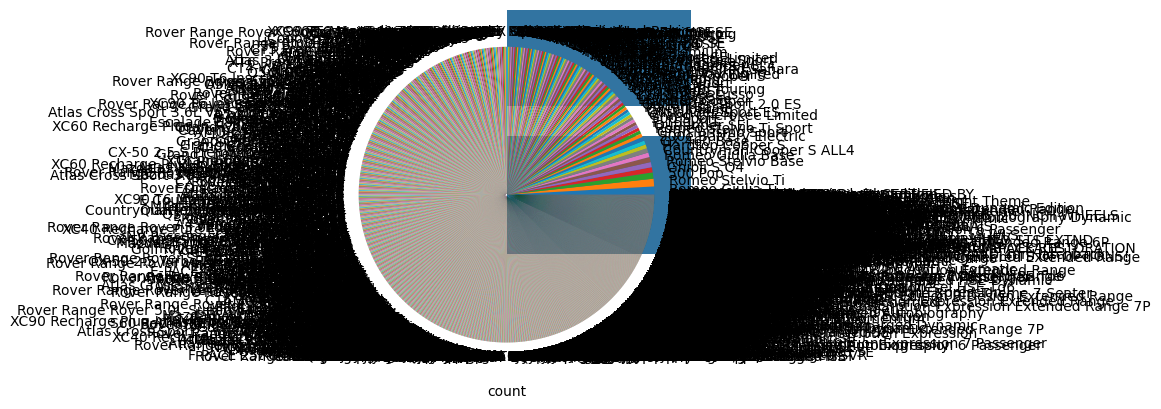

In [17]:
sns.countplot(df["model"])

df["model"].value_counts().plot(kind="pie")

/tmp/ipykernel_5975/50337492.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["price"])


<Axes: xlabel='price', ylabel='Density'>

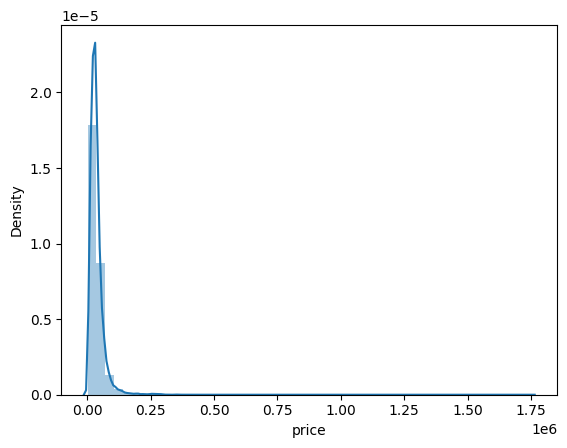

In [44]:
sns.distplot(df["price"])

In [45]:
df.shape

(19109, 36)

In [47]:
df.describe()

,year,mileage,engine_size,automatic_transmission,min_mpg,max_mpg,damaged,first_owner,personal_using,turbo,...,automatic_emergency_braking,stability_control,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,price
count,19107.000000,19107.000000,17860.000000,19107.000000,16103.000000,16103.000000,18940.000000,18803.000000,18920.000000,19107.000000,...,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,19107.000000,1.907500e+04
mean,2017.773120,47947.087403,2.973191,0.917098,20.827796,27.817270,0.217371,0.517417,0.718288,0.404250,...,0.174386,0.949600,0.696603,0.486000,0.148741,0.387240,0.870100,0.351547,0.485320,3.696284e+04
std,4.996385,38285.061200,5.478008,0.275741,6.017846,6.513062,0.412468,0.499710,0.449846,0.490759,...,0.379451,0.218775,0.459737,0.499817,0.355843,0.487132,0.336202,0.477466,0.499798,3.512381e+04
min,1962.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.495000e+03
25%,2016.000000,19307.000000,2.000000,1.000000,17.000000,24.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.079700e+04
50%,2019.000000,39141.000000,2.500000,1.000000,20.000000,28.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.099500e+04
75%,2021.000000,68431.500000,3.500000,1.000000,24.000000,31.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,4.395000e+04
max,2024.000000,383614.000000,390.000000,1.000000,89.000000,100.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.750000e+06


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19109 entries, 0 to 19108
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   brand                        19107 non-null  object 
 1   model                        19107 non-null  object 
 2   year                         19107 non-null  float64
 3   mileage                      19107 non-null  float64
 4   engine                       19062 non-null  object 
 5   engine_size                  17860 non-null  float64
 6   transmission                 19004 non-null  object 
 7   automatic_transmission       19107 non-null  float64
 8   fuel_type                    19107 non-null  object 
 9   drivetrain                   19107 non-null  object 
 10  min_mpg                      16103 non-null  float64
 11  max_mpg                      16103 non-null  float64
 12  damaged                      18940 non-null  float64
 13  first_owner     

In [18]:
df.isnull().sum()

brand                             2
model                             2
year                              2
mileage                           2
engine                           47
engine_size                    1249
transmission                    105
automatic_transmission            2
fuel_type                         2
drivetrain                        2
min_mpg                        3006
max_mpg                        3006
damaged                         169
first_owner                     306
personal_using                  189
turbo                             2
alloy_wheels                      2
adaptive_cruise_control           2
navigation_system                 2
power_liftgate                    2
backup_camera                     2
keyless_start                     2
remote_start                      2
sunroof/moonroof                  2
automatic_emergency_braking       2
stability_control                 2
leather_seats                     2
memory_seat                 

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'engine_size'}>,
        <Axes: title={'center': 'automatic_transmission'}>,
        <Axes: title={'center': 'min_mpg'}>],
       [<Axes: title={'center': 'max_mpg'}>,
        <Axes: title={'center': 'damaged'}>,
        <Axes: title={'center': 'first_owner'}>,
        <Axes: title={'center': 'personal_using'}>,
        <Axes: title={'center': 'turbo'}>],
       [<Axes: title={'center': 'alloy_wheels'}>,
        <Axes: title={'center': 'adaptive_cruise_control'}>,
        <Axes: title={'center': 'navigation_system'}>,
        <Axes: title={'center': 'power_liftgate'}>,
        <Axes: title={'center': 'backup_camera'}>],
       [<Axes: title={'center': 'keyless_start'}>,
        <Axes: title={'center': 'remote_start'}>,
        <Axes: title={'center': 'sunroof/moonroof'}>,
        <Axes: title={'center': 'automatic_emergency_braking'}>,
        <Axes: title={'center': '

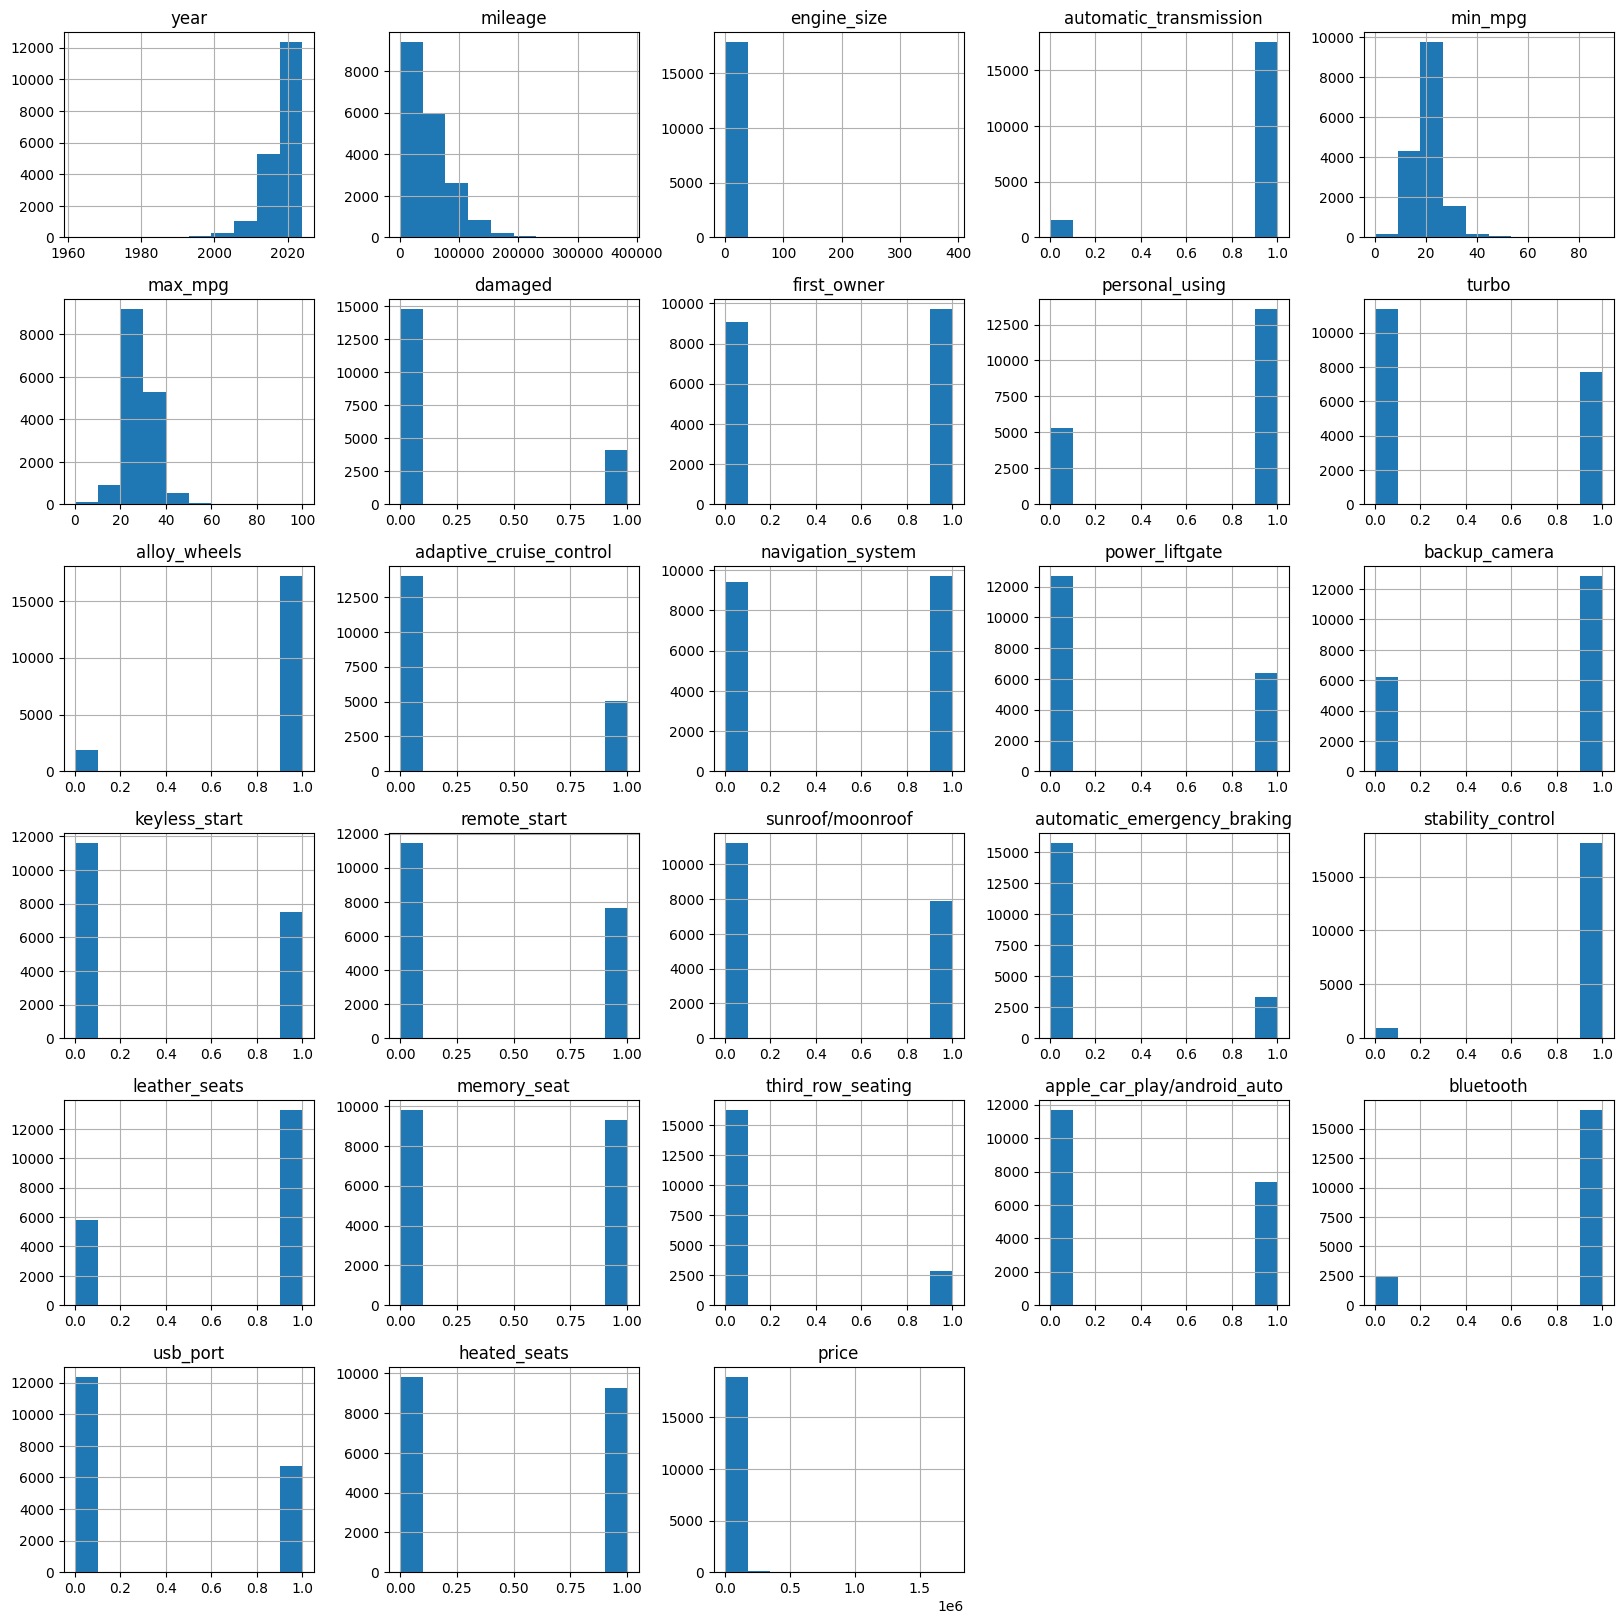

In [53]:
df.hist(figsize=(20, 20)) # 20 by 20 20 ki hist plot draw kiya fig ka size bhi btaya

In [14]:
df.corr(numeric_only=True)["price"].sort_values()

mileage                       -0.382971
max_mpg                       -0.192871
min_mpg                       -0.181492
damaged                       -0.156571
usb_port                      -0.056651
stability_control             -0.028598
automatic_emergency_braking   -0.023426
alloy_wheels                  -0.021181
bluetooth                     -0.019154
keyless_start                 -0.012934
personal_using                 0.015935
third_row_seating              0.041677
automatic_transmission         0.042835
engine_size                    0.055615
backup_camera                  0.068198
remote_start                   0.082965
heated_seats                   0.092024
sunroof/moonroof               0.107561
adaptive_cruise_control        0.111242
turbo                          0.126510
power_liftgate                 0.146763
first_owner                    0.157401
leather_seats                  0.157513
apple_car_play/android_auto    0.168414
memory_seat                    0.211276


<Axes: xlabel='mileage', ylabel='price'>

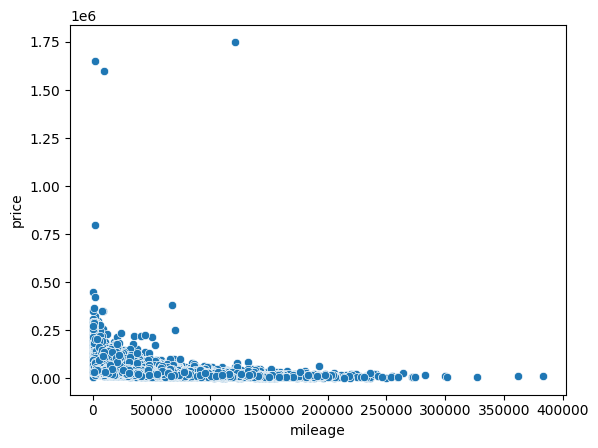

In [57]:
sns.scatterplot(data=df,x="mileage",y="price")  

<Axes: xlabel='fuel_type', ylabel='price'>

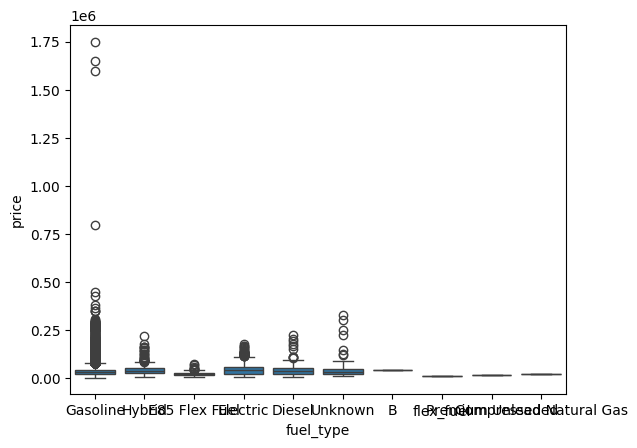

In [58]:
sns.boxplot(data=df,x="fuel_type",y="price")

<Axes: xlabel='price'>

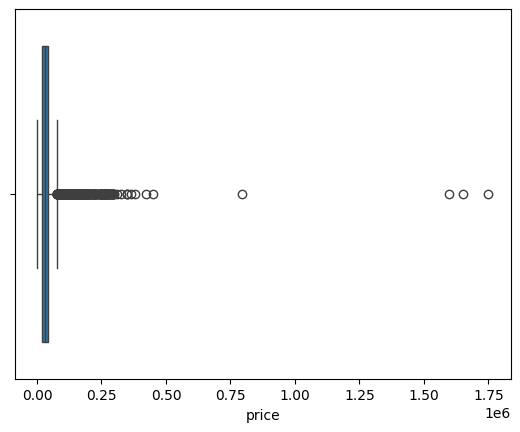

In [59]:
sns.boxplot(x=df["price"])

In [15]:
df["car_age"] = 2026 - df["year"]

In [16]:
df["car_age"].sample(10)

554       5.0
14509    10.0
15550    10.0
9503      8.0
626       6.0
16458     7.0
14539    10.0
13362     6.0
827       4.0
7330      8.0
Name: car_age, dtype: float64

In [17]:
df["mileage_per_year"] = df["mileage"] / (df["car_age"] + 1) # how far our car travels in 1 litre petrol so we are getting one year car milete by diving it with car age 

df["mileage_per_year"]

0         1316.000000
1         6968.555556
2         3092.600000
3          256.200000
4         6121.166667
             ...     
19104     7788.600000
19105     4417.285714
19106     4248.333333
19107     3855.000000
19108    10009.727273
Name: mileage_per_year, Length: 19109, dtype: float64

In [15]:
df.drop("car_age", axis=1, inplace=True)
df.drop("mileage_per_year",axis=1,inplace=True)

KeyError: "['car_age'] not found in axis"

In [16]:
df = df.dropna(subset=["price"])

In [20]:
x = df.drop(
    columns=[
        "automatic_transmission",
        "min_mpg",
        "max_mpg",
        "damaged",
        "first_owner",
        "personal_using",
        "turbo",
        "alloy_wheels",
        "adaptive_cruise_control",
        "navigation_system",
        "power_liftgate",
        "backup_camera",
        "keyless_start",
        "remote_start",
        "sunroof/moonroof",
        "automatic_emergency_braking",
        "stability_control",
        "leather_seats",
        "memory_seat",
        "third_row_seating",
        "apple_car_play/android_auto",
        "bluetooth",
        "usb_port",
        "heated_seats",
        "fuel_type",
        "drivetrain",
        "transmission",
        "interior_color",
        "exterior_color",
        "engine",
        "price"
    ]
)

y = df["price"]

In [21]:
x

,brand,model,year,mileage,engine_size
0,Mazda,CX-9 Touring,2022.0,6580.0,2.5
1,Alfa,Romeo Stelvio 4DR SUV AWD,2018.0,62717.0,2.9
2,Chevrolet,Silverado 1500 Limited LT,2022.0,15463.0,5.3
3,Land,Rover Range Rover P400 SE,2022.0,1281.0,3.0
4,Mitsubishi,Outlander Sport 2.0 SE,2021.0,36727.0,2.0
...,...,...,...,...,...
19104,Lexus,RC 350 Base,2017.0,77886.0,3.5
19105,Chevrolet,Camaro 2SS,2020.0,30921.0,6.2
19106,Hyundai,Palisade Calligraphy,2021.0,25490.0,3.8
19107,Honda,Accord Sport,2019.0,30840.0,1.5


In [22]:
y = pd.to_numeric(y, errors="coerce")

In [23]:
y.isnull().mean()

np.float64(0.0)

In [24]:
y.head()

0     36789.0
1     39993.0
2     46986.0
3    141999.0
4     21595.0
Name: price, dtype: float64

In [25]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [26]:
X_train.shape

(15260, 5)

In [38]:
X_test.shape

(3822, 6)

In [27]:
numerical_cols = x.select_dtypes(include="number").columns
categorical_cols = x.select_dtypes(include="object").columns

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
preprocessor = ColumnTransformer([

    ("num",num_pipeline,numerical_cols),
    ("cat",cat_pipeline,categorical_cols)
])

In [29]:
# finally complete model pipeline

# LInearRegression gives us = 82 % score
# RandomForestGives us = 86%

model = Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",RandomForestRegressor(n_estimators=30,random_state=42,n_jobs=1))
])

In [30]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred

array([16578.2       , 37332.83333333, 19438.06666667, ...,
       68993.73333333, 38320.43333333, 63987.63333333], shape=(3815,))

In [34]:
print("R2 Score ",r2_score(y_test,y_pred)) 

R2 Score  0.8402556561149959


In [35]:
with open("models/car_price_predict_model.pkl", "wb") as file:
    pickle.dump(model,file)

In [36]:
print("Numerical:")
print(numerical_cols.tolist())

print("\nCategorical:")
print(categorical_cols.tolist())

Numerical:
['year', 'mileage', 'engine_size']

Categorical:
['brand', 'model']


In [15]:
X = df.drop("price", axis=1)
y = df["price"]

numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)
print("Target:", y.name)

Numerical: ['year', 'mileage', 'engine_size', 'automatic_transmission', 'min_mpg', 'max_mpg', 'damaged', 'first_owner', 'personal_using', 'turbo', 'alloy_wheels', 'adaptive_cruise_control', 'navigation_system', 'power_liftgate', 'backup_camera', 'keyless_start', 'remote_start', 'sunroof/moonroof', 'automatic_emergency_braking', 'stability_control', 'leather_seats', 'memory_seat', 'third_row_seating', 'apple_car_play/android_auto', 'bluetooth', 'usb_port', 'heated_seats']
Categorical: ['brand', 'model', 'engine', 'transmission', 'fuel_type', 'drivetrain', 'interior_color', 'exterior_color']
Target: price


In [18]:
print(X.iloc[0].to_dict())

{'brand': 'Mazda', 'model': 'CX-9 Touring', 'year': 2022.0, 'mileage': 6580.0, 'engine': '2.5L I4 16V GDI DOHC Turbo', 'engine_size': 2.5, 'transmission': '6-Speed Automatic', 'automatic_transmission': 1.0, 'fuel_type': 'Gasoline', 'drivetrain': 'Four-wheel Drive', 'min_mpg': nan, 'max_mpg': nan, 'damaged': 0.0, 'first_owner': 0.0, 'personal_using': 0.0, 'turbo': 1.0, 'alloy_wheels': 1.0, 'adaptive_cruise_control': 0.0, 'navigation_system': 0.0, 'power_liftgate': 1.0, 'backup_camera': 1.0, 'keyless_start': 0.0, 'remote_start': 0.0, 'sunroof/moonroof': 1.0, 'automatic_emergency_braking': 0.0, 'stability_control': 1.0, 'leather_seats': 1.0, 'memory_seat': 0.0, 'third_row_seating': 1.0, 'apple_car_play/android_auto': 1.0, 'bluetooth': 0.0, 'usb_port': 0.0, 'heated_seats': 1.0, 'interior_color': 'Black', 'exterior_color': 'Snowflake White Pearl'}


In [19]:
categorical_columns = [
    "brand",
    "model",
    "engine",
    "transmission",
    "fuel_type",
    "drivetrain",
    "interior_color",
    "exterior_color"
]

for col in categorical_columns:
    print(f"\n===== {col} =====")
    print(df[col].dropna().unique().tolist())


===== brand =====
['Mazda', 'Alfa', 'Chevrolet', 'Land', 'Mitsubishi', 'FIAT', 'Kia', 'Audi', 'Honda', 'Jeep', 'Mercedes-Benz', 'Porsche', 'MINI', 'Nissan', 'Jaguar', 'Toyota', 'BMW', 'Lexus', 'Volvo', 'Hyundai', 'Maserati', 'Cadillac', 'Ford', 'Volkswagen', 'Suzuki']

===== model =====
['CX-9 Touring', 'Romeo Stelvio 4DR SUV AWD', 'Silverado 1500 Limited LT', 'Rover Range Rover P400 SE', 'Outlander Sport 2.0 SE', '500 Sport', 'Carnival LXS', 'SQ5 3.0T Premium', 'Pilot Special Edition', 'Grand Cherokee Altitude', 'GL-Class GL 450 4MATIC', 'Outlander Sport SE', '968', 'Hardtop Cooper', 'Rover Range Rover Velar S', 'Rover Range Rover Sport Supercharged HSE', 'Sentra SV', 'CX-3 Touring', 'Romeo Stelvio Ti', 'Niro LXS', 'F-PACE SVR', 'Sorento X-Line EX', 'Convertible John Cooper Works', 'A8 L 3.0T', 'Grand Cherokee Limited', 'Avalon Limited', 'X3 M40i', '911 GT3', '124 Spider Abarth', 'Tahoe High Country', 'Titan S', 'Prius Prime Premium', 'NX 200t F Sport', 'Countryman Cooper S ALL4', 'X

In [20]:
sample = X.sample(1, random_state=42)

sample.T

,18553
brand,Maserati
model,Ghibli S Q4
year,2021.0
mileage,6017.0
engine,3.0L V6 24V GDI DOHC Twin Turbo
engine_size,3.0
transmission,8-Speed Automatic
automatic_transmission,1.0
fuel_type,Gasoline
drivetrain,Four-wheel Drive
